# Results: coeffs from optimisation after DEAP

Visually inspect the admissions coefficients from the optimisation results. Calculate r-squared values to decide which coefficients are the best.

__Inputs:__

+ Optimised coefficients from `minimize`
+ Optimised coefficients from simulated annealing
+ MSOA-level admissions and population data for calculating admissions from resulting coefficients.

__Results:__

+ Data: final admissions coefficients.
  + One coefficient for each combination of age band and deprivation quantile, and one set of coefficients for: the best option; minimal values; maximal values. 

__Method:__

Compare the results from the optimisation function with the input coefficients. Scatter the input and output coefficients to check how much they have changed.

Calculate r-squared values for the simulated annealing results. Use the set with the best r-squared as the final coefficients.

__Conclusion:__

The results don't all converge on a similar set of values from all 100 starting points.
Use the result with the best r-squared as the chosen coefficients,
and use the range of values as an idea of accuracy.
Round the results to 1 (2) significant figures because of this range of values. Can't justify being any more precise when clearly all of them give pretty good results.

## Code setup

In [1]:
import os
import polars as pl
from scipy.optimize import minimize, basinhopping
import numpy as np
import matplotlib.pyplot as plt

## Load starting coeffs

from best DEAP results

Check results:

In [2]:
df_coeffs_init = pl.read_csv(os.path.join('genetic_algorithms', 'outputs', 'post_deap_inputs_for_opt.csv'))

df_coeffs_init

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.000597,0.004482,0.004503,0.007166,0.013902,0.000486,0.003129,0.004482,0.007166,0.012731,0.000392,0.002639,0.003735,0.006005,0.012492,0.000347,0.002114,0.003639,0.005995,0.011558,0.00033,0.002099,0.003361,0.004804,0.010753
"""randomseed41""",0.0005712,0.003687,0.00557,0.007206,0.013597,0.000512,0.003102,0.004036,0.006306,0.013006,0.000408,0.002785,0.003735,0.006005,0.011558,0.0003264,0.002542,0.003735,0.006005,0.011558,0.0003264,0.002115,0.002988,0.005458,0.011352
"""randomseed47""",0.000616,0.003407,0.004956,0.008039,0.01387,0.000454,0.003168,0.004482,0.006757,0.012985,0.000405,0.0028,0.003735,0.006103,0.011558,0.000368,0.00245,0.003508,0.005757,0.011426,0.000308,0.002352,0.003225,0.004918,0.011426
"""randomseed65""",0.000565,0.004515,0.005976,0.006535,0.013649,0.000491,0.003125,0.004482,0.006535,0.012831,0.000403,0.002644,0.003735,0.006005,0.011781,0.000372,0.00261,0.00361,0.00583,0.011451,0.000323,0.0015864,0.002607,0.005822,0.01135
"""randomseed81""",0.000602,0.003702,0.005229,0.006653,0.01387,0.000452,0.0031728,0.004419,0.006653,0.013686,0.000406,0.002644,0.003735,0.006005,0.011866,0.000366,0.002577,0.00371,0.006005,0.010991,0.000326,0.002091,0.002988,0.005577,0.010991
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed60""",0.0005712,0.003678,0.005229,0.008407,0.014667,0.000485,0.0031728,0.004482,0.007206,0.01387,0.000408,0.002644,0.003652,0.006005,0.011558,0.000363,0.002644,0.003652,0.005286,0.010891,0.000325,0.002115,0.002988,0.004804,0.010726
"""randomseed83""",0.00054,0.003572,0.005011,0.008407,0.014775,0.000471,0.0031728,0.004482,0.007206,0.013694,0.000408,0.002823,0.003735,0.005965,0.011558,0.000408,0.002644,0.003714,0.00525,0.011558,0.0003264,0.001959,0.002988,0.004804,0.010213
"""randomseed98""",0.0005712,0.003663,0.004891,0.008407,0.015371,0.0004896,0.0031728,0.003989,0.006255,0.014048,0.000408,0.002644,0.003735,0.006005,0.011558,0.000354,0.002644,0.003735,0.005725,0.011551,0.0003264,0.002137,0.003398,0.004804,0.009687


Pick out the directory names: 

In [3]:
# best_dirs = df_best_gens.filter(np.round(df_best_gens['r2_all'], 3) == np.round(df_best_gens['r2_all'].max(), 3))['dir'].to_numpy()
best_dirs = df_coeffs_init['coeff_combo'].to_numpy()

Coefficient names:

In [4]:
coeff_names = [
    'age_less65_q00',
    'age_65_q00',
    'age_70_q00',
    'age_75_q00',
    'age_over80_q00',
    'age_less65_q02',
    'age_65_q02',
    'age_70_q02',
    'age_75_q02',
    'age_over80_q02',
    'age_less65_q04',
    'age_65_q04',
    'age_70_q04',
    'age_75_q04',
    'age_over80_q04',
    'age_less65_q06',
    'age_65_q06',
    'age_70_q06',
    'age_75_q06',
    'age_over80_q06',
    'age_less65_q08',
    'age_65_q08',
    'age_70_q08',
    'age_75_q08',
    'age_over80_q08'
]

### Load optimisation results

Minimize:

In [5]:
df_results = pl.read_csv(os.path.join('genetic_algorithms', 'outputs', 'post_deap_multi_optimise_coeffs_results.csv'))

Annealing:

In [6]:
df_ann_results = pl.read_csv(os.path.join('genetic_algorithms', 'outputs', 'post_deap_multi_basinhop_coeffs_results.csv'))

### View minimize results

In [7]:
df_results#[coeff_names]

coeff_combo,message,success,status,nit,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""","""Optimization terminated succes…",true,0,438,869,0.496,0.58,0.63865,0.60782,0.61611,0.59205,237.872,0.0005943,0.0044859,0.0045138,0.007188,0.0139038,0.0004852,0.0031233,0.0044872,0.0071635,0.0126489,0.0003905,0.0026363,0.0037408,0.0060114,0.0124872,0.000349,0.0021195,0.0036495,0.0059937,0.0115054,0.0003314,0.0021014,0.0033617,0.0048194,0.0107622
"""randomseed41""","""Optimization terminated succes…",true,0,555,979,0.4944,0.58288,0.63506,0.60678,0.61932,0.59195,237.901,0.0005711,0.0036941,0.0055439,0.0071915,0.013603,0.0005125,0.0031065,0.0040363,0.0062997,0.0130672,0.0004109,0.0027873,0.0037476,0.0060181,0.0115882,0.0003293,0.0025422,0.0037173,0.0059698,0.011566,0.0003262,0.0021283,0.0029849,0.0054645,0.0113556
"""randomseed47""","""Optimization terminated succes…",true,0,504,968,0.49496,0.57926,0.63493,0.60791,0.62019,0.59169,237.978,0.000613,0.0034109,0.0049707,0.0079223,0.0138519,0.0004518,0.0031676,0.004481,0.0066927,0.0129607,0.0004066,0.0027992,0.0037416,0.0060326,0.0116013,0.0003699,0.0024579,0.0034959,0.0057663,0.0114467,0.0003093,0.0023638,0.0032348,0.0049349,0.0113895
"""randomseed65""","""Optimization terminated succes…",true,0,499,933,0.49441,0.58167,0.63621,0.60609,0.62006,0.59197,237.897,0.0005597,0.0044858,0.0059303,0.0065995,0.0136842,0.0004901,0.0031015,0.0044538,0.0065356,0.0128348,0.0004066,0.0026388,0.0036866,0.0059569,0.0119035,0.0003722,0.0026107,0.0036075,0.0058368,0.0113949,0.0003256,0.0016134,0.0025957,0.0058287,0.011366
"""randomseed81""","""Optimization terminated succes…",true,0,580,1004,0.49603,0.57988,0.63711,0.60628,0.61822,0.59179,237.95,0.0005925,0.0036624,0.0052648,0.0065693,0.0139197,0.0004519,0.0031534,0.0041839,0.0065518,0.0135912,0.0004038,0.0026694,0.0037936,0.0061147,0.0119159,0.0003697,0.0026204,0.0036869,0.0059019,0.0111037,0.0003357,0.0021464,0.0030361,0.0056294,0.0109578


Compare with starting values:

In [8]:
df_coeffs_init.filter(df_coeffs_init['coeff_combo'].is_in(df_results['coeff_combo']))

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed04""",0.000597,0.004482,0.004503,0.007166,0.013902,0.000486,0.003129,0.004482,0.007166,0.012731,0.000392,0.002639,0.003735,0.006005,0.012492,0.000347,0.002114,0.003639,0.005995,0.011558,0.00033,0.002099,0.003361,0.004804,0.010753
"""randomseed41""",0.0005712,0.003687,0.00557,0.007206,0.013597,0.000512,0.003102,0.004036,0.006306,0.013006,0.000408,0.002785,0.003735,0.006005,0.011558,0.0003264,0.002542,0.003735,0.006005,0.011558,0.0003264,0.002115,0.002988,0.005458,0.011352
"""randomseed47""",0.000616,0.003407,0.004956,0.008039,0.01387,0.000454,0.003168,0.004482,0.006757,0.012985,0.000405,0.0028,0.003735,0.006103,0.011558,0.000368,0.00245,0.003508,0.005757,0.011426,0.000308,0.002352,0.003225,0.004918,0.011426
"""randomseed65""",0.000565,0.004515,0.005976,0.006535,0.013649,0.000491,0.003125,0.004482,0.006535,0.012831,0.000403,0.002644,0.003735,0.006005,0.011781,0.000372,0.00261,0.00361,0.00583,0.011451,0.000323,0.0015864,0.002607,0.005822,0.01135
"""randomseed81""",0.000602,0.003702,0.005229,0.006653,0.01387,0.000452,0.0031728,0.004419,0.006653,0.013686,0.000406,0.002644,0.003735,0.006005,0.011866,0.000366,0.002577,0.00371,0.006005,0.010991,0.000326,0.002091,0.002988,0.005577,0.010991


Plot starting vs optimised values:

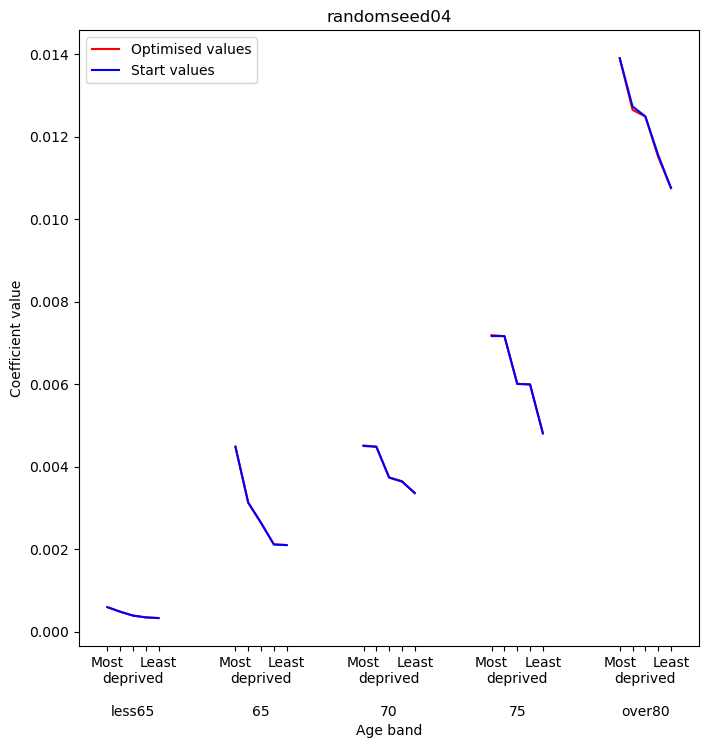

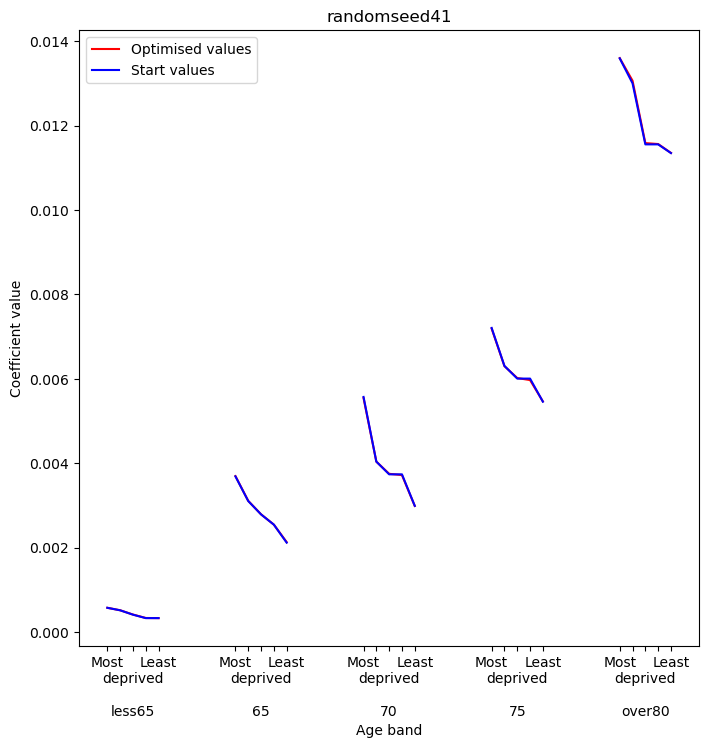

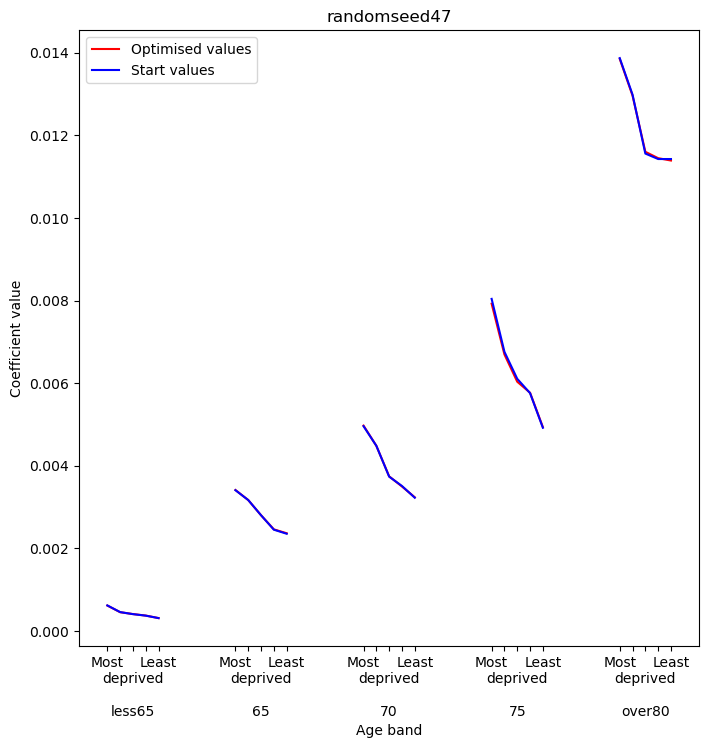

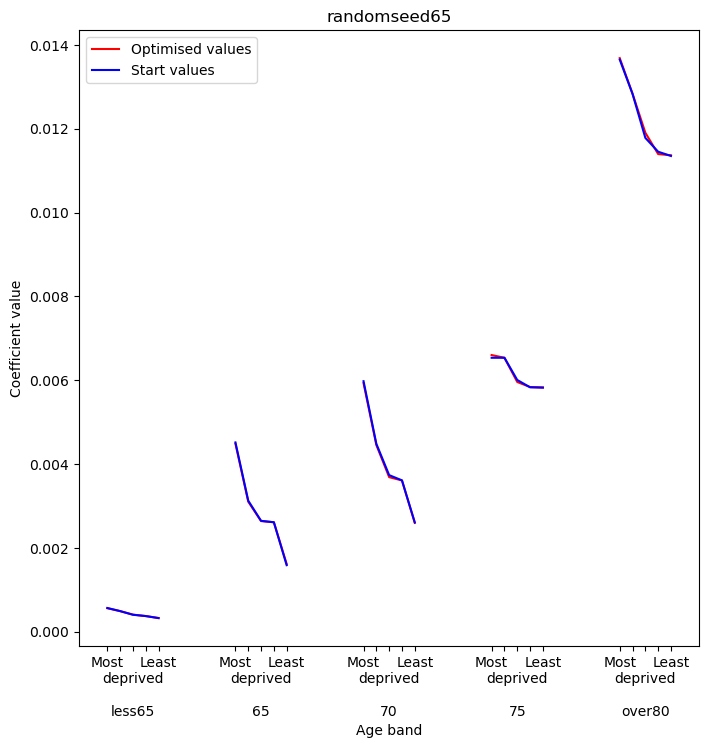

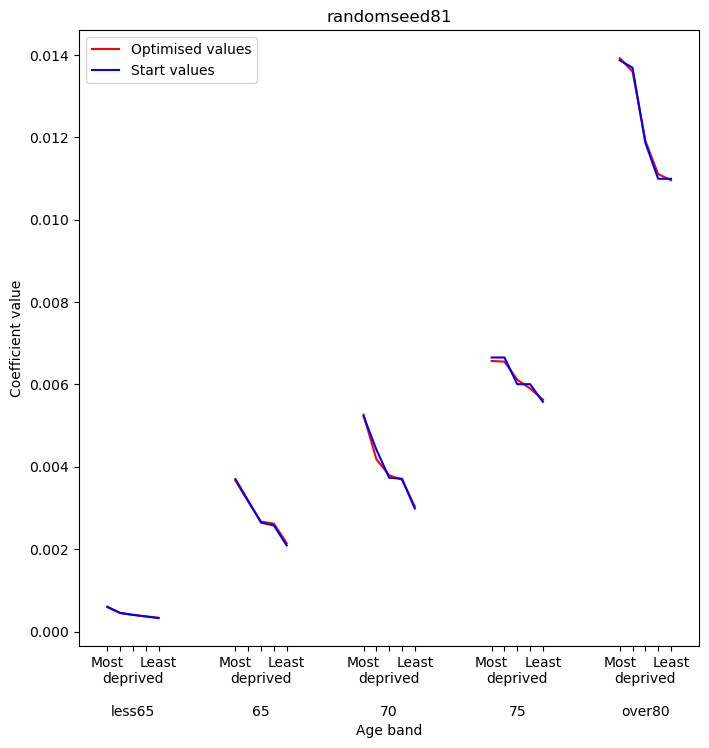

In [9]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

for coeff_combo in df_results['coeff_combo']:
    fig, ax = plt.subplots(figsize=(8, 8))

    for a, age in enumerate(age_bands):
        coeff_names_here = [c for c in df_results.columns if c.startswith(f'age_{age}')]
        
        ax.plot(x_offsets + a, df_results.filter(df_results['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='r', label=('Optimised values' if a == 0 else None))
        ax.plot(x_offsets + a, df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='b', label=('Start values' if a == 0 else None))
        
    # ax.set_xticks(np.arange(len(age_bands)))
    # ax.set_xticks(xticks_minor, minor=True)
    # ax.set_xticklabels(age_bands)
    ax.set_xticks(xticks_minor)
    ax.set_xticklabels(qmin_labels)
    
    ax.legend()
    ax.set_title(coeff_combo)
    ax.set_xlabel('Age band')
    ax.set_ylabel('Coefficient value')
    plt.show()

Optimised values haven't changed much from the inputs, so assume that these are local minima rather than global. Rely on the annealing results instead.

### View post-annealing results

View results:

In [10]:
df_ann_results.sort('r2_all', descending=True)

coeff_combo,message,success,nit,minimization_failures,nfev,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08,r2_all,res,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,str,bool,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed15""","""requested number of basinhoppi…",true,100,0,109665,0.49603,0.58189,0.63766,0.60951,0.62133,0.59356,237.433,0.0006294,0.00339,0.006573,0.0069397,0.0121848,0.000523,0.0032394,0.0046271,0.0063534,0.0121827,0.0004,0.0030352,0.0034647,0.0062635,0.0121326,0.0003611,0.0026149,0.002969,0.0056608,0.0119939,0.0002279,0.0019295,0.0029079,0.0056607,0.0119332
"""randomseed95""","""requested number of basinhoppi…",true,100,0,112269,0.49609,0.58138,0.63748,0.60883,0.62199,0.59342,237.474,0.0006105,0.0039282,0.0050174,0.0076273,0.0130249,0.0005219,0.0027405,0.0045816,0.0070862,0.0123435,0.0003904,0.0026548,0.0040108,0.005788,0.0121354,0.0003769,0.0024979,0.0033019,0.0054829,0.0116925,0.0002449,0.0024349,0.0030779,0.0053215,0.0116155
"""randomseed31""","""requested number of basinhoppi…",true,100,0,111991,0.49668,0.58252,0.63663,0.60748,0.62222,0.59334,237.498,0.0006504,0.0035075,0.0050357,0.0069418,0.013036,0.0005251,0.0032405,0.0043631,0.0062476,0.0123882,0.000367,0.003054,0.0038563,0.0061388,0.0119904,0.0003279,0.0025737,0.0035384,0.0058777,0.0117954,0.0002691,0.0018647,0.0031354,0.0056335,0.0116037
"""randomseed53""","""requested number of basinhoppi…",true,100,0,113104,0.49665,0.58177,0.63754,0.60824,0.62116,0.59333,237.5,0.0006287,0.0044088,0.0045837,0.0071455,0.0128388,0.0004931,0.0031293,0.0042775,0.0067528,0.0127514,0.0004009,0.0025444,0.0039706,0.0061818,0.0121444,0.0003396,0.0022534,0.0034906,0.0060611,0.0117106,0.0002821,0.0021056,0.0034248,0.004925,0.011408
"""randomseed77""","""requested number of basinhoppi…",true,100,0,116813,0.49657,0.58285,0.63631,0.60745,0.62167,0.5932,237.538,0.0006308,0.0033924,0.0046398,0.0074256,0.0137218,0.0005269,0.0033085,0.0039687,0.0060948,0.0125377,0.0003843,0.003229,0.0039076,0.0060053,0.0118253,0.0003347,0.0023853,0.0036133,0.0059816,0.0115462,0.0002646,0.0019175,0.003557,0.0054752,0.0114786
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""randomseed18""","""requested number of basinhoppi…",true,100,0,118480,0.49292,0.58157,0.63774,0.60743,0.61642,0.59159,238.006,0.000579,0.0030535,0.0051298,0.0084107,0.0144879,0.0005134,0.0029051,0.0045666,0.007035,0.0122385,0.0004133,0.0028881,0.0037305,0.0057218,0.0122332,0.0003888,0.0027358,0.0033993,0.0053914,0.0112985,0.0002544,0.002481,0.0031777,0.0050455,0.0111306
"""randomseed74""","""requested number of basinhoppi…",true,100,0,114806,0.49417,0.57953,0.63631,0.60788,0.61857,0.59159,238.006,0.0005871,0.0036832,0.0051967,0.0081662,0.0136541,0.0004711,0.0031009,0.0045537,0.0068565,0.0130652,0.000385,0.0027624,0.0037454,0.0063289,0.0118422,0.0003664,0.0025586,0.0035581,0.0054695,0.011482,0.0003435,0.0021484,0.0029734,0.0047009,0.0111888
"""randomseed97""","""requested number of basinhoppi…",true,100,0,113504,0.49291,0.58172,0.63696,0.60637,0.61774,0.59149,238.036,0.0005476,0.0034344,0.005,0.0073999,0.0149065,0.000494,0.0030188,0.0041674,0.0069273,0.0126168,0.0004082,0.0027732,0.0037524,0.0061595,0.011835,0.0003894,0.0024835,0.0035512,0.005636,0.011566,0.0003163,0.0024704,0.0033873,0.0050883,0.0107054


View all post-annealing coefficient sets:

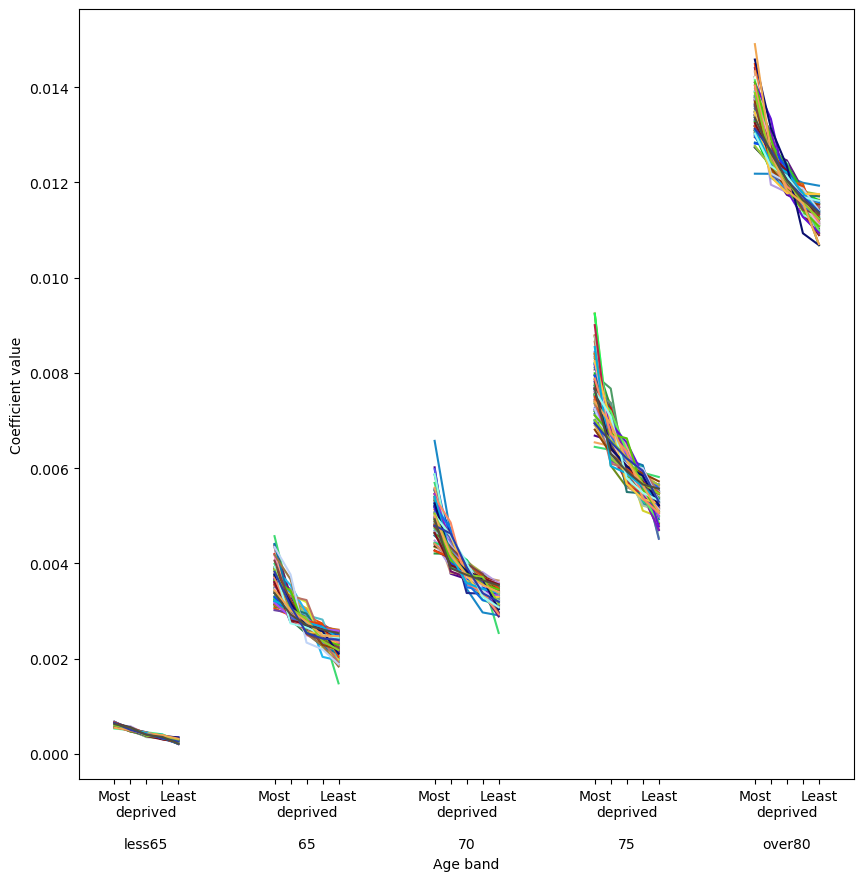

In [11]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])
qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

fig, ax = plt.subplots(figsize=(10, 10))

# colours = ['b', 'r']
# labels = ['DEAP', 'DEAP then anneal']

for results_dir in df_ann_results['coeff_combo']:
    # Pick out coeffs:
    # coeffs = df_best_gens.filter(df_best_gens['dir'] == results_dir)[coeff_names].to_numpy().flatten()
    coeffs_ann = df_ann_results.filter(df_ann_results['coeff_combo'] == results_dir)[coeff_names].to_numpy().flatten()
    # for i, coeffs in enumerate([coeffs, coeffs_ann]):
    for i, coeffs in enumerate([coeffs_ann]):
        # if results_dir in df_best_gens_topr2['dir']:
        colour = np.random.rand(3,)
        # colour = colours[i]
        zorder = 5
        alpha = 1.0
        # else:
        #     colour = 'silver'
        #     zorder = 4
        #     alpha = 0.4
        # g = gen_attr(df_coeffs_init)
    
        offset = -0.2
        for c in range(5):
            # xs = np.arange(5) + offset
            # ys = g[c*5:(c*5)+5]
            xs = x_offsets + c
            
            ys = np.array(coeffs)[np.arange(0, 25, 5) + c]
            ax.plot(xs, ys, color=colour, zorder=zorder, alpha=alpha, 
                    # label=labels[i] if c < 1 else None)
                    label=(results_dir if c==0 else None))
            offset += 0.1
        
ax.set_xticks(xticks_minor)
ax.set_xticklabels(qmin_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Coefficient value')
# ax.legend()

plt.show()

In [12]:
coeffs_ann

array([0.0006244, 0.0033736, 0.0049279, 0.0076644, 0.0133593, 0.0005484,
       0.0029261, 0.0038978, 0.0063045, 0.0126201, 0.0003991, 0.0027026,
       0.0037573, 0.005931 , 0.0120483, 0.0003539, 0.0026086, 0.0036449,
       0.005658 , 0.0116294, 0.0002137, 0.0025339, 0.0035368, 0.0055681,
       0.0113591])

Still seeing a range in final coefficients. Haven't converged on one set of ``best'' coefficients from all of the different starting points.

Plot starting vs optimised values for the same subset as the `minimize` results:

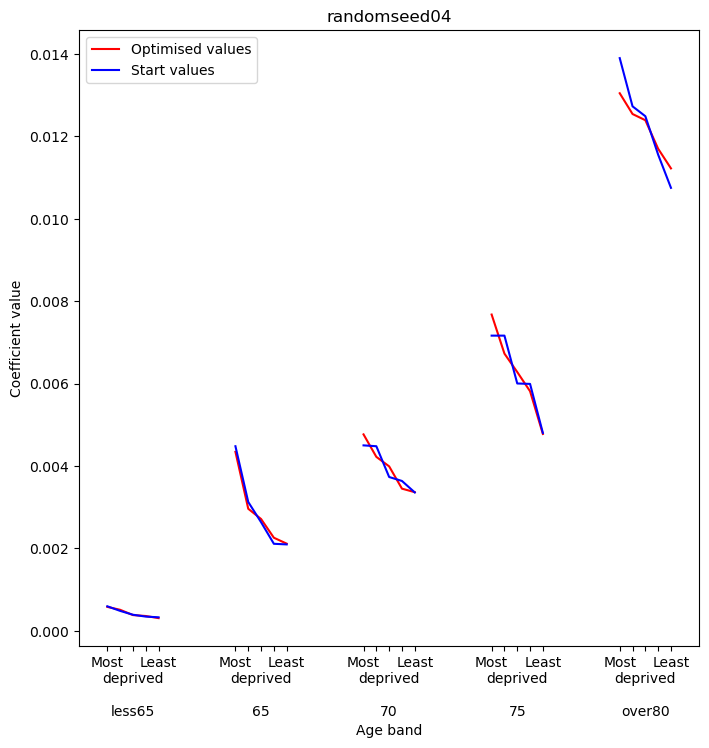

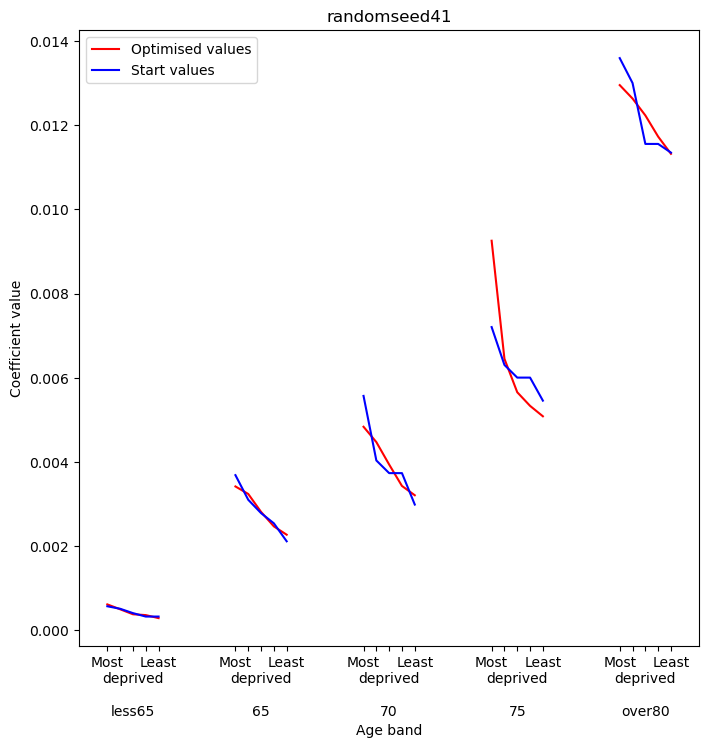

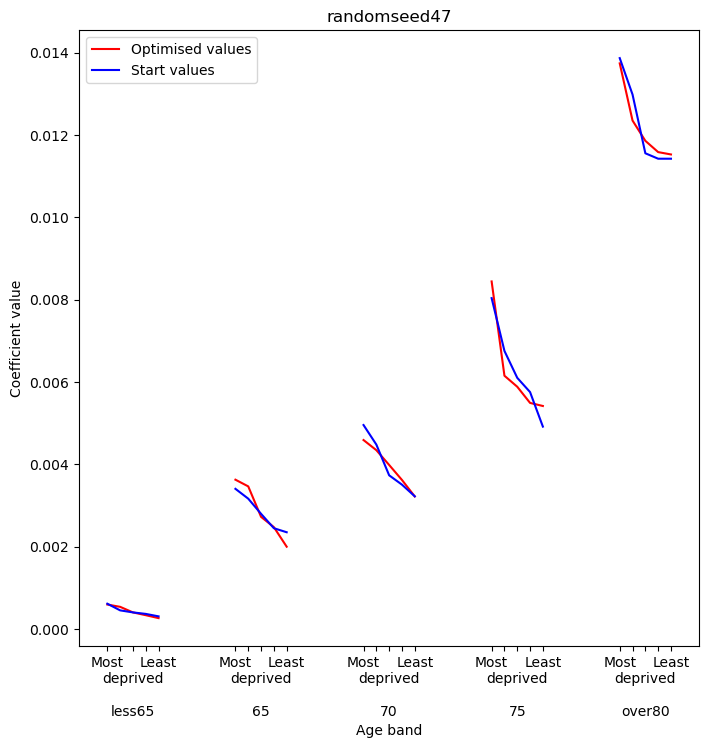

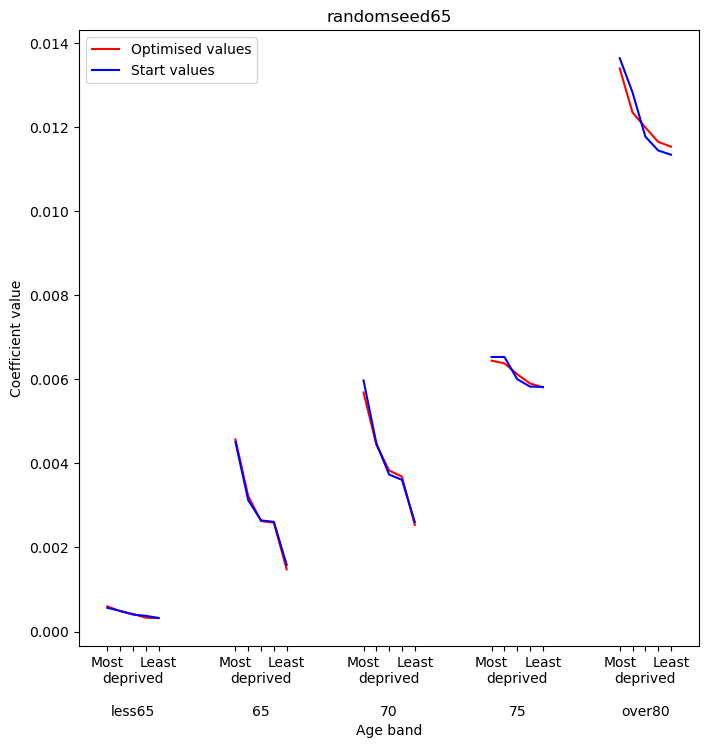

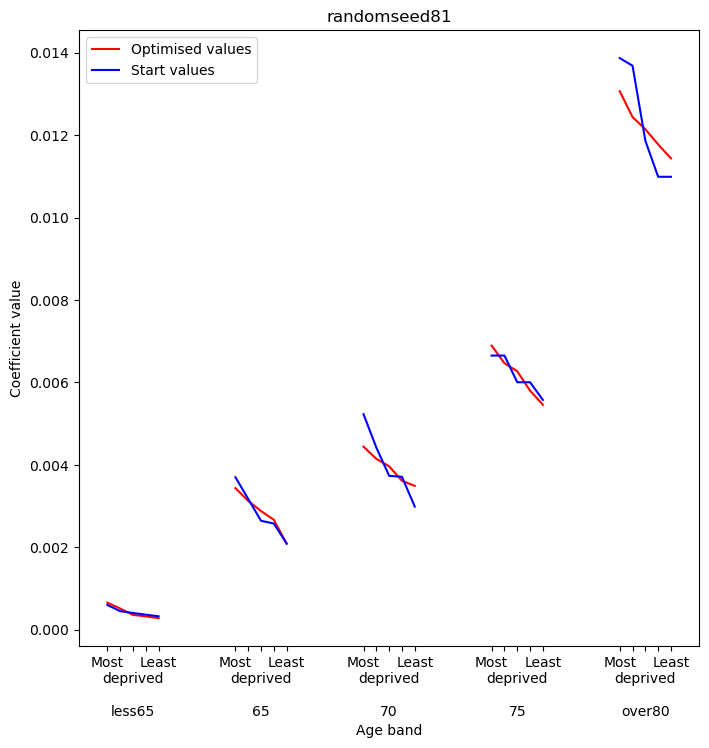

In [13]:
age_bands = ['less65', '65', '70', '75', 'over80']
x_offsets = np.arange(-0.2, 0.3, 0.1)
xticks_minor = np.concatenate([x_offsets + a for a in range(len(age_bands))])

qmin_labels = np.concatenate([['Most', '', '' + '\ndeprived\n\n' + age_band, '', 'Least'] for age_band in age_bands])

for coeff_combo in df_results['coeff_combo']:
    fig, ax = plt.subplots(figsize=(8, 8))

    for a, age in enumerate(age_bands):
        coeff_names_here = [c for c in df_ann_results.columns if c.startswith(f'age_{age}')]
        
        ax.plot(x_offsets + a, df_ann_results.filter(df_ann_results['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='r', label=('Optimised values' if a == 0 else None))
        ax.plot(x_offsets + a, df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == coeff_combo)[coeff_names_here].to_numpy().flatten(), color='b', label=('Start values' if a == 0 else None))
        
    # ax.set_xticks(np.arange(len(age_bands)))
    # ax.set_xticks(xticks_minor, minor=True)
    # ax.set_xticklabels(age_bands)
    ax.set_xticks(xticks_minor)
    ax.set_xticklabels(qmin_labels)
    
    ax.legend()
    ax.set_title(coeff_combo)
    ax.set_xlabel('Age band')
    ax.set_ylabel('Coefficient value')
    plt.show()

Seeing more difference from the starting values this time so have more trust that these derived coefficients are actually optimised.

### Pick out best result

Pick out only the coefficient sets whose r-squared value matches the best:

In [14]:
mask = np.round(df_ann_results['r2_all'], 3) == np.round(df_ann_results['r2_all'].max(), 3)

df_best_ann = df_ann_results.filter(mask)[coeff_names]

In [15]:
df_best_ann

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0006294,0.00339,0.006573,0.0069397,0.0121848,0.000523,0.0032394,0.0046271,0.0063534,0.0121827,0.0004,0.0030352,0.0034647,0.0062635,0.0121326,0.0003611,0.0026149,0.002969,0.0056608,0.0119939,0.0002279,0.0019295,0.0029079,0.0056607,0.0119332


Only one set of coefficients!

Compare with start values:

In [16]:
best_ann_dir = df_ann_results.filter(mask)['coeff_combo'][0]

df_coeffs_init.filter(df_coeffs_init['coeff_combo'] == best_ann_dir)

coeff_combo,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed15""",0.000689,0.003591,0.004408,0.007206,0.014043,0.000408,0.0031728,0.004314,0.007193,0.013838,0.000394,0.002693,0.003778,0.006289,0.011649,0.000394,0.002644,0.003735,0.005717,0.010997,0.000261,0.002139,0.003494,0.004804,0.010974


View range of resulting coefficients:

In [17]:
df_max = df_ann_results.max()[coeff_names]
df_min = df_ann_results.min()[coeff_names]
df_range = df_max - df_min

df = pl.concat((df_min, df_max, df_range, df_best_ann))

for col in coeff_names:
    if 'less65' in col:
        n = 4
    elif 'over80' in col:
        n = 3
    else:
        n = 3
    df = df.with_columns(pl.col(col).round(n))

df * 100.0

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.05,0.3,0.4,0.6,1.2,0.05,0.3,0.4,0.6,1.2,0.04,0.2,0.3,0.5,1.2,0.03,0.2,0.3,0.5,1.1,0.02,0.1,0.3,0.5,1.1
0.07,0.5,0.7,0.9,1.5,0.06,0.4,0.5,0.8,1.3,0.05,0.3,0.4,0.7,1.2,0.04,0.3,0.4,0.6,1.2,0.03,0.3,0.4,0.6,1.2
0.01,0.2,0.2,0.3,0.3,0.01,0.1,0.1,0.2,0.1,0.01,0.1,0.1,0.1,0.1,0.01,0.1,0.1,0.1,0.1,0.01,0.1,0.1,0.1,0.1
0.06,0.3,0.7,0.7,1.2,0.05,0.3,0.5,0.6,1.2,0.04,0.3,0.3,0.6,1.2,0.04,0.3,0.3,0.6,1.2,0.02,0.2,0.3,0.6,1.2


View just the best coefficients:

In [18]:
(df_best_ann * 100.0).to_numpy().reshape(5, 5)

array([[0.06294, 0.339  , 0.6573 , 0.69397, 1.21848],
       [0.0523 , 0.32394, 0.46271, 0.63534, 1.21827],
       [0.04   , 0.30352, 0.34647, 0.62635, 1.21326],
       [0.03611, 0.26149, 0.2969 , 0.56608, 1.19939],
       [0.02279, 0.19295, 0.29079, 0.56607, 1.19332]])

View just the best coefficients, rounded, and the minimum and maximum values seen:

In [19]:
for df in df_best_ann, df_min, df_max:
    
    for col in coeff_names:
        if 'less65' in col:
            n = 4
        elif 'over80' in col:
            n = 3
        else:
            n = 3
        df = df.with_columns(pl.col(col).round(n))
    
    display((df * 100.0).to_numpy().reshape(5, 5))

array([[0.06, 0.3 , 0.7 , 0.7 , 1.2 ],
       [0.05, 0.3 , 0.5 , 0.6 , 1.2 ],
       [0.04, 0.3 , 0.3 , 0.6 , 1.2 ],
       [0.04, 0.3 , 0.3 , 0.6 , 1.2 ],
       [0.02, 0.2 , 0.3 , 0.6 , 1.2 ]])

array([[0.05, 0.3 , 0.4 , 0.6 , 1.2 ],
       [0.05, 0.3 , 0.4 , 0.6 , 1.2 ],
       [0.04, 0.2 , 0.3 , 0.5 , 1.2 ],
       [0.03, 0.2 , 0.3 , 0.5 , 1.1 ],
       [0.02, 0.1 , 0.3 , 0.5 , 1.1 ]])

array([[0.07, 0.5 , 0.7 , 0.9 , 1.5 ],
       [0.06, 0.4 , 0.5 , 0.8 , 1.3 ],
       [0.05, 0.3 , 0.4 , 0.7 , 1.2 ],
       [0.04, 0.3 , 0.4 , 0.6 , 1.2 ],
       [0.03, 0.3 , 0.4 , 0.6 , 1.2 ]])

Save a copy of the best coefficients:

In [20]:
age_labels = {
    'less65': 'less65',
    '65': '65-70',
    '70': '70-75',
    '75': '75-80',
    'over80': 'over80',
}

In [21]:
qmin_list = np.round(np.arange(0.0, 1.0, 0.2), 1)

In [22]:
dfs_to_save_dict = {
    'best': df_best_ann,
    'min': df_min,
    'max': df_max,
}

dfs_to_save = []

for label, df in dfs_to_save_dict.items(): 
    df_to_save = (df).to_numpy().reshape(5, 5)
    
    # df_to_save = np.hstack((np.array(['00_most', '02', '04', '06', '08_least']).reshape(5, 1), df_to_save))
    df_to_save = np.hstack((np.array(qmin_list).reshape(5, 1), df_to_save))
    df_to_save = np.hstack((np.array([label]*5).reshape(5, 1), df_to_save))
    
    age_cols = list(age_labels.values())  #[f'age_{a}' for a in age_bands]
    df_to_save = pl.DataFrame(df_to_save, schema=['coeff_set', 'depriv_quantile_min'] + age_cols)
    
    # Convert coeff columns to float:
    df_to_save = df_to_save.cast(dict(zip(age_cols, [float]*len(age_cols))))
    df_to_save = df_to_save.cast(dict(depriv_quantile_min=float))
    # Round values again to prevent floating point error:
    for col in age_cols:
        if 'less65' in col:
            n = 4
        elif 'over80' in col:
            n = 3
        else:
            n = 3
        df_to_save = df_to_save.with_columns(pl.col(col).round(n))
    df_to_save = df_to_save.with_columns(pl.col('depriv_quantile_min').round(1))
    dfs_to_save.append(df_to_save)

df_to_save = pl.concat(dfs_to_save)

In [23]:
with pl.Config(tbl_rows=15):
    display(df_to_save)

coeff_set,depriv_quantile_min,less65,65-70,70-75,75-80,over80
str,f64,f64,f64,f64,f64,f64
"""best""",0.0,0.0006,0.003,0.007,0.007,0.012
"""best""",0.2,0.0005,0.003,0.005,0.006,0.012
"""best""",0.4,0.0004,0.003,0.003,0.006,0.012
"""best""",0.6,0.0004,0.003,0.003,0.006,0.012
"""best""",0.8,0.0002,0.002,0.003,0.006,0.012
"""min""",0.0,0.0005,0.003,0.004,0.006,0.012
"""min""",0.2,0.0005,0.003,0.004,0.006,0.012
"""min""",0.4,0.0004,0.002,0.003,0.005,0.012
"""min""",0.6,0.0003,0.002,0.003,0.005,0.011


In [24]:
df_to_save.write_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

In [3]:
import polars as pl
import os

In [5]:
df_final_coeffs = pl.read_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

In [6]:
df_final_coeffs

coeff_set,depriv_quantile_min,less65,65-70,70-75,75-80,over80
str,f64,f64,f64,f64,f64,f64
"""best""",0.0,0.0006,0.003,0.007,0.007,0.012
"""best""",0.2,0.0005,0.003,0.005,0.006,0.012
"""best""",0.4,0.0004,0.003,0.003,0.006,0.012
"""best""",0.6,0.0004,0.003,0.003,0.006,0.012
"""best""",0.8,0.0002,0.002,0.003,0.006,0.012
…,…,…,…,…,…,…
"""max""",0.0,0.0007,0.005,0.007,0.009,0.015
"""max""",0.2,0.0006,0.004,0.005,0.008,0.013
"""max""",0.4,0.0005,0.003,0.004,0.007,0.012


In [8]:
qmin_list = sorted(df_final_coeffs['depriv_quantile_min'].unique())

In [9]:
age_cols = ['less65', '65-70', '70-75', '75-80', 'over80']

In [10]:
df_final_coeffs_best = df_final_coeffs.filter(df_final_coeffs['coeff_set'] == 'best')
df_final_coeffs_min = df_final_coeffs.filter(df_final_coeffs['coeff_set'] == 'min')
df_final_coeffs_max = df_final_coeffs.filter(df_final_coeffs['coeff_set'] == 'max')

In [13]:
q_labels = {
    0.0: '0% to 20% (most deprived)',
    0.2: '20% to 40%',
    0.4: '40% to 60%',
    0.6: '60% to 80%',
    0.8: '80% to 100% (least deprived)'
    }

In [18]:
print('| Deprivation quantile | Under 65 | 65 to 69 | 70 to 74 | 75 to 80 | Over 80 |')
print('| --- | --- | --- | --- | --- | --- |')
for q, qmin in enumerate(qmin_list):
    q_str = q_labels[qmin]
    row = f'| {q_str} |'
    for age_col in age_cols:
        coeff_best = df_final_coeffs_best.filter(df_final_coeffs_best['depriv_quantile_min'] == qmin)[age_col].to_numpy()[0]
        coeff_min = df_final_coeffs_min.filter(df_final_coeffs_best['depriv_quantile_min'] == qmin)[age_col].to_numpy()[0]
        coeff_max = df_final_coeffs_max.filter(df_final_coeffs_best['depriv_quantile_min'] == qmin)[age_col].to_numpy()[0]
        row += f' {round(100.0*coeff_best, 6)}% ({round(100.0*coeff_min, 6)}%--{round(100.0*coeff_max, 6)}%) |'
    print(row)

| Deprivation quantile | Under 65 | 65 to 69 | 70 to 74 | 75 to 80 | Over 80 |
| --- | --- | --- | --- | --- | --- |
| 0% to 20% (most deprived) | 0.06% (0.05%--0.07%) | 0.3% (0.3%--0.5%) | 0.7% (0.4%--0.7%) | 0.7% (0.6%--0.9%) | 1.2% (1.2%--1.5%) |
| 20% to 40% | 0.05% (0.05%--0.06%) | 0.3% (0.3%--0.4%) | 0.5% (0.4%--0.5%) | 0.6% (0.6%--0.8%) | 1.2% (1.2%--1.3%) |
| 40% to 60% | 0.04% (0.04%--0.05%) | 0.3% (0.2%--0.3%) | 0.3% (0.3%--0.4%) | 0.6% (0.5%--0.7%) | 1.2% (1.2%--1.2%) |
| 60% to 80% | 0.04% (0.03%--0.04%) | 0.3% (0.2%--0.3%) | 0.3% (0.3%--0.4%) | 0.6% (0.5%--0.6%) | 1.2% (1.1%--1.2%) |
| 80% to 100% (least deprived) | 0.02% (0.02%--0.03%) | 0.2% (0.1%--0.3%) | 0.3% (0.3%--0.4%) | 0.6% (0.5%--0.6%) | 1.2% (1.1%--1.2%) |
